In [ ]:
### Cargamos el modelo phi-4
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_id = "microsoft/phi-4-mini-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_lm = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", torch_dtype="auto")
generator = pipeline("text-generation", model=model_lm, tokenizer=tokenizer)

c:\Users\PC\Maestria\NLP\RAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PC\Maestria\NLP\RAG\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PC\.cache\huggingface\hub\models--microsoft--phi-4-mini-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate dev

## Modelo en cpu

In [37]:
import torch
model_lm_cpu = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map={"": "cpu"},   
    torch_dtype=torch.float32 
)
generator_cpu = pipeline("text-generation", model=model_lm_cpu, tokenizer=tokenizer)

Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.33s/it]
Device set to use cpu


In [2]:
import pickle
#Usaremos los embedding y metadatos usados anteriormente
with open(f"../outputs/embeddings_gemma_y_metadatos.pkl", "rb") as f:
    data = pickle.load(f)

embeddings = data["embeddings"]
metadatos = data["metadatos"]

In [3]:
#Uso FAISS para indexar
#FAISS es una librería desarrollada por Meta (Facebook) para hacer búsqueda rápida de vectores por similitud, ideal cuando tienes muchos embeddings (como en RAG).
import faiss
import numpy as np
embedding_matrix = np.array(embeddings)

# Crear índice FAISS (búsqueda por similitud L2 o Euclidiana)
dim = embedding_matrix.shape[1] 
print(dim)
index = faiss.IndexFlatL2(dim)  

# Agregar los vectores al índice
index.add(embedding_matrix)

# Guardar el índice en disco
faiss.write_index(index, "../outputs/faiss_index.index")

768


### RAG + DSLR

In [4]:
import spacy
nlp = spacy.load("en_core_web_sm")

def dividir_oraciones(texto):
    doc = nlp(texto)
    return [sent.text.strip() for sent in doc.sents]

In [5]:
from sentence_transformers import CrossEncoder


def re_rank_oraciones(question, oraciones):
    reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [(question, sent) for sent in oraciones]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(oraciones, scores), key=lambda x: x[1], reverse=True)
    return ranked

In [6]:
import numpy as np

def filtrar_por_umbral(oraciones_ranked, percentil=90):
    scores = [score for _, score in oraciones_ranked]
    umbral = np.percentile(scores, percentil)
    oraciones_filtradas = [(sent, score) for sent, score in oraciones_ranked if score >= umbral]
    return oraciones_filtradas, umbral

In [7]:
def reconstruir_contexto(oraciones_filtradas, oraciones_originales):
    oraciones_validas = set([sent for sent, _ in oraciones_filtradas])
    reconstruido = [sent for sent in oraciones_originales if sent in oraciones_validas]
    return reconstruido

In [8]:
## Funcion para implementar los 3 pasos de DSLR 
def refine_documents(sentence,pregunta):
    # Paso 1: Separar oraciones
    oraciones = dividir_oraciones(sentence)

    # Paso 2: Rankear oraciones
    oraciones_ranked = re_rank_oraciones(pregunta, oraciones)

    # Paso 3: Filtrar con percentil 90
    oraciones_filtradas, umbral = filtrar_por_umbral(oraciones_ranked, percentil=90)

    # Paso 4: Reconstruir en orden original
    oraciones_reconstruidas = reconstruir_contexto(oraciones_filtradas, oraciones)

    # Resultado final para pasar al LLM
    documento_refinado = " ".join(oraciones_reconstruidas)
    return documento_refinado
         

In [9]:
import pandas as pd
# Cargar el archivo CSV
df_qa = pd.read_csv("../dataQA/qa.txt")
df_qa.head()

,chunk,question,answer
0,seawater seawater tds mgl considered standard ...,What types of water are classified based on To...,Water is classified into categories like seawa...
1,recovery limit salinity andor boron concentrat...,Why is it important to limit product recovery ...,Limiting product recovery is important to ensu...
2,design boynton beach fl membrane softening wat...,How is the maximum recovery value determined f...,The maximum recovery value is determined by co...
3,range rather absolute value temperature variat...,Why is average temperature used for performanc...,Average temperature is used because membrane p...
4,risk scaling due water scarcity environmental ...,Why must scaling substances be removed from tr...,"Even after secondary treatment, wastewater can..."


In [35]:
import time
## Implementamos DSLR en nuestro pipeline
def responder_con_phi4_con_contexto_refinado_latencia(generator,pregunta, modelo_embedding, indice,k=5, inEnglish= False,is_CPU = False):
     # Embeddear la pregunta
    pregunta_vec = modelo_embedding.encode([pregunta])

    # Buscar k chunks relevantes en FAISS
    D, I = index.search(np.array(pregunta_vec), k)

    # Recuperar los chunks y sus títulos
    chunks_usados = []
    contexto = ""
    for idx in I[0]:
        doc = metadatos[idx]
        chunk_text = doc["chunk"].strip()
        titulo = doc.get("id_doc", "Sin título")

        chunks_usados.append({
            "titulo": titulo,
            "chunk": chunk_text
        })
    chunk_filtrado = [] 
    # Finalización recuperación
    t_retrieved = time.time()
    if is_CPU:
        df_qa.at[indice, "t_retrieved_cpu"] = t_retrieved
    else:
        df_qa.at[indice, "t_retrieved"] = t_retrieved
    for document in chunks_usados:
        texto_refinado=refine_documents(document["chunk"],pregunta)
        chunk_filtrado.append({
            "titulo": titulo,
            "chunk": texto_refinado
        })
        contexto += f"- {texto_refinado}\n"
    t_refined = time.time()
    if is_CPU:
        df_qa.at[indice, "t_refined_cpu"] = t_refined
    else:
        df_qa.at[indice, "t_refined"] = t_refined
        
    idioma = "La respuesta tiene que ser obligatoriamente en ingles" if inEnglish else "" 
    # Construir prompt para Phi-4
    prompt = f"<|user|>\nUsa el siguiente contexto para responder la pregunta de manera clara y precisa.\n\nContexto:\n{contexto}\nPregunta: {pregunta} {idioma}\n<|assistant|>"
    
    # Generar respuesta
    output = generator(
        prompt,
        max_new_tokens=300,
        temperature=0.5,
        do_sample=True
    )[0]["generated_text"]

    respuesta = output[len(prompt):].strip()

    return {
        "pregunta": pregunta,
        "respuesta": respuesta,
        "chunks_usados": chunk_filtrado
    }

In [ ]:

from sentence_transformers import SentenceTransformer
modelo_embedding = SentenceTransformer("google/embeddinggemma-300m")
# Generaremos las respuestas con el modelo con RAG y lo almacenaremos
for i, row in df_qa.head(100).iterrows():
    pregunta = row["question"]
    inicio = time.time()
    df_qa.at[i, "inicio"] = inicio
    resultado = responder_con_phi4_con_contexto_refinado_latencia(generator,pregunta, modelo_embedding,i,5,True)
    fin= time.time()
    df_qa.at[i, "fin"] = fin
    
    df_qa.at[i, "latencia"] = fin - inicio
    

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


## Ejecucion Modelo en CPU

In [ ]:


# Generaremos las respuestas con el modelo con RAG y lo almacenaremos
for i, row in df_qa.head(100).iterrows():
    pregunta = row["question"]
    inicio = time.time()
    df_qa.at[i, "inicio_cpu"] = inicio
    resultado = responder_con_phi4_con_contexto_refinado_latencia(generator_cpu,pregunta, modelo_embedding,i,5,True, True)
    fin= time.time()
    df_qa.at[i, "fin_cpu"] = fin
    
    df_qa.at[i, "latencia_cpu"] = fin - inicio

In [15]:
df_qa.to_csv("../dataQA/df_qa_dslr_latencia.csv", index=False)

### Metricas latencia

In [ ]:
df_qa = pd.read_csv("../dataQA/qa.txt")

In [20]:
df_qa.head()

,chunk,question,answer,inicio,t_retrieved,t_refined,fin,latencia
0,seawater seawater tds mgl considered standard ...,What types of water are classified based on To...,Water is classified into categories like seawa...,1.765490e+09,1.765490e+09,1.765490e+09,1.765490e+09,14.104344
1,recovery limit salinity andor boron concentrat...,Why is it important to limit product recovery ...,Limiting product recovery is important to ensu...,1.765490e+09,1.765490e+09,1.765490e+09,1.765490e+09,12.495756
2,design boynton beach fl membrane softening wat...,How is the maximum recovery value determined f...,The maximum recovery value is determined by co...,1.765490e+09,1.765490e+09,1.765490e+09,1.765490e+09,14.349469
3,range rather absolute value temperature variat...,Why is average temperature used for performanc...,Average temperature is used because membrane p...,1.765490e+09,1.765490e+09,1.765490e+09,1.765490e+09,19.775575
4,risk scaling due water scarcity environmental ...,Why must scaling substances be removed from tr...,"Even after secondary treatment, wastewater can...",1.765490e+09,1.765490e+09,1.765490e+09,1.765490e+09,12.641596


In [ ]:
T_inicio= df_qa.head(100)["inicio"].mean()
T_retrieved = df_qa.head(100)["t_retrieved"].mean() - T_inicio
T_refined = df_qa.head(100)["t_refined"].mean() - T_inicio
T_fin = df_qa.head(100)["fin"].mean() - T_inicio

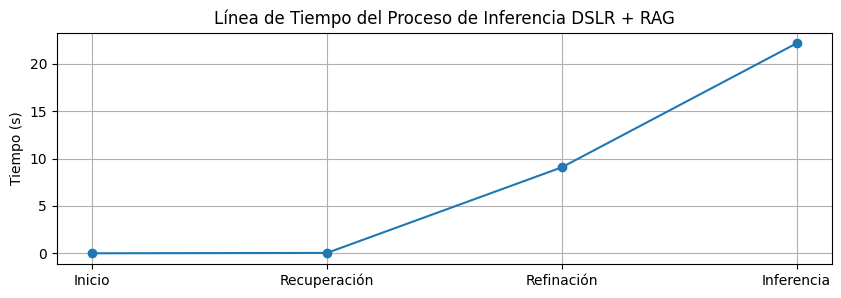

In [28]:
import matplotlib.pyplot as plt

# Tiempos en ms
eventos = ['Inicio', 'Recuperación', 'Refinación', 'Inferencia']
tiempos = [0, T_retrieved, T_refined, T_fin]

plt.figure(figsize=(10,3))
plt.plot(eventos, tiempos, marker='o')
plt.title('Línea de Tiempo del Proceso de Inferencia DSLR + RAG')
plt.ylabel('Tiempo (s)')
plt.grid(True)

plt.show()

## Diagrama de caja

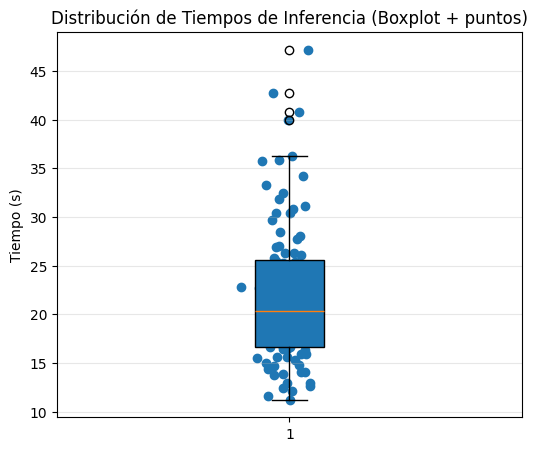

In [30]:
import matplotlib.pyplot as plt
import numpy as np
tiempos_s = df_qa.head(100)["latencia"].tolist()
plt.figure(figsize=(6,5))

plt.boxplot(tiempos_s, vert=True, patch_artist=True)


x = np.random.normal(1, 0.03, size=len(tiempos_s))
plt.scatter(x, tiempos_s)

plt.ylabel('Tiempo (s)')
plt.title('Distribución de Tiempos de Inferencia (Boxplot + puntos)')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [31]:
print(tiempos_s)

[14.104343891143799, 12.495755910873413, 14.349469423294067, 19.775574684143066, 12.64159631729126, 14.999475002288818, 12.952606916427612, 17.18416714668274, 25.0009663105011, 14.073522567749023, 16.684598445892334, 11.614086627960205, 15.316744089126587, 13.90942668914795, 15.633957386016846, 20.388638257980347, 15.947914600372314, 12.090790748596191, 21.81943655014038, 18.467498779296875, 21.98150086402893, 24.458931922912598, 16.616732358932495, 19.779924631118774, 15.983970403671265, 17.7097008228302, 16.48894429206848, 19.95643424987793, 19.475497007369995, 22.760054111480713, 22.690898418426514, 17.147958755493164, 18.179380893707275, 24.53974223136902, 24.89785933494568, 11.235443115234375, 36.25753664970398, 16.431872844696045, 42.69507884979248, 12.996033906936646, 35.91024971008301, 24.57005023956299, 26.949349880218506, 30.781728744506836, 19.98904848098755, 25.772645950317383, 21.3067626953125, 17.554683685302734, 18.22040820121765, 39.95119643211365, 29.690988063812256, 1

In [32]:
import numpy as np

prom = np.mean(tiempos_s)
med = np.median(tiempos_s)
std = np.std(tiempos_s)
p95 = np.percentile(tiempos_s, 95)
p50 = np.percentile(tiempos_s, 50)

print("Promedio:", prom)
print("Mediana:", med)
print("Desviación estándar:", std)
print("Percentil 95:", p95)
print("Percentil 50:", p50)

Promedio: 22.17321354866028
Mediana: 20.32785475254059
Desviación estándar: 7.287384283853275
Percentil 95: 35.927614057064055
Percentil 50: 20.32785475254059


### Metricas CPU

In [ ]:
T_inicio= df_qa.head(100)["inicio_cpu"].mean()
T_retrieved = df_qa.head(100)["t_retrieved_cpu"].mean() - T_inicio
T_refined = df_qa.head(100)["t_refined_cpu"].mean() - T_inicio
T_fin = df_qa.head(100)["fin_cpu"].mean() - T_inicio

In [ ]:
import matplotlib.pyplot as plt

# Tiempos en ms
eventos = ['Inicio', 'Recuperación', 'Refinación', 'Inferencia']
tiempos = [0, T_retrieved, T_refined, T_fin]

plt.figure(figsize=(10,3))
plt.plot(eventos, tiempos, marker='o')
plt.title('Línea de Tiempo del Proceso de Inferencia DSLR + RAG')
plt.ylabel('Tiempo (s)')
plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
tiempos_s = df_qa.head(100)["latencia_cpu"].tolist()
plt.figure(figsize=(6,5))

plt.boxplot(tiempos_s, vert=True, patch_artist=True)


x = np.random.normal(1, 0.03, size=len(tiempos_s))
plt.scatter(x, tiempos_s)

plt.ylabel('Tiempo (s)')
plt.title('Distribución de Tiempos de Inferencia (Boxplot + puntos)')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
import numpy as np

prom = np.mean(tiempos_s)
med = np.median(tiempos_s)
std = np.std(tiempos_s)
p95 = np.percentile(tiempos_s, 95)
p50 = np.percentile(tiempos_s, 50)

print("Promedio:", prom)
print("Mediana:", med)
print("Desviación estándar:", std)
print("Percentil 95:", p95)
print("Percentil 50:", p50)